# Übung 4

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

## In dieser Übung ...

... werden wir ein Modell trainieren, um handgeschriebene Ziffern voneinander zu unterscheiden. Dabei wird *Feature Engineering*, also die Generierung von Merkmalen für unser Machine Learning Modell, im Fokus stehen. Nebenbei werden wir auch einige Lerninhalte wiederholen und festigen, die Sie in den letzten Übungen kennengelernt haben. Für die Klassifikation von handgeschriebenen Ziffern werden wir unser Perzeptron anpassen und den Pocket-Algorithmus kennenlernen, implementieren (Übung 4.1) und auf synthetischen Daten testen (Übung 4.2). Den Pocket-Algorithmus werden wir dann für die Klassifikation handgeschriebener Ziffern einsetzen (Übung 4.3).

Unser Vorgehen ist ganz klassisch: Sie lernen einen neuen Algorithmus kennen und untersuchen ihn auf synthetischen Daten. Das ist die "Laborsituation", in der wir alle Randbedingungen unter Kontrolle haben, bevor Sie dann den Algorithmus auf "echte" Daten (die handgeschriebenen Ziffern) anwenden.

### 4.1 Der Pocket-Algorithmus
Wir benötigen für unsere heutige Klassifikationsaufgabe einen Algorithmus, der auch bei Datensätzen funktioniert, die **nicht** linear separierbar sind. Eine einfache und robuste (wenn auch nicht hocheffiziente) Möglichkeit dazu bietet der Pocket-Algorithmus. Bevor ich Ihnen unten den Algorithmus spezifiziere, ist hier seine Grundidee: Der Pocket-Algorithmus führt einen Lernschritt mithilfe des Perzeptron-Lern-Algorithmus (PLA) durch und prüft, ob der In-Sample-Fehler nach dem Lernschritt kleiner geworden ist. Falls dem so ist, merkt sich dies der Pocket-Algorithmus (er "steckt den Gewichtsvektor des Perzeptron in seine Tasche" (engl. "pocket")) und führt den nächsten PLA-Schritt durch. Wenn der Prozess am Ende abgebrochen wird, befindet sich in seiner Tasche der Gewichtsvektor (und damit die Gerade), die die Daten am besten (d.h. mit kleinstem In-Sample-Fehler) separiert.

Hier ist der Algorithmus:

Sei $\mathbf{\hat{w}}$ der Gewichtsvektor des Pocket-Algorithmus. Sei $t$ der Iterationsschritt (eine Laufvariable), der von $0$ bis $(T-1)$ läuft. Sei $\mathbf{w}^{(t)}$ der Gewichtsvektor von PLA zum Iterationsschritt $t$.

(1) Setze $\mathbf{\hat{w}}=\mathbf{w}^{(0)}=\mathbf{0}$. Setze den In-Sample Fehler $E_{in}(\mathbf{\hat{w}}) = 1$.

(2) Für $t=0,\ldots,T-1$, führe aus:

> 1. Starte PLA mit $\mathbf{w}^{(t)}$ und lasse PLA ein einziges Gewichtsupdate durchführen. Erhalte $\mathbf{w}^{(t+1)}$ .
> 2. Ermittle den In-Sample Fehler $E_{in}(\mathbf{w}^{(t+1)})$ für den Trainingsdatensatz.
> 3. Wenn $E_{in}(\mathbf{w}^{(t+1)}) < E_{in}(\mathbf{\hat{w}})$, dann setze  $\mathbf{\hat{w}}=\mathbf{w}^{(t+1)}$

(3) Gebe $\mathbf{\hat{w}}$ zurück.

**Implementierungshinweise**

* Um etwas Rechenzeit zu sparen, ist es nützlich, jeweils den vergangenen In-Sample Fehler für $\mathbf{\hat{w}}$ in einer Variablen zu speichern, sodass Sie in Schritt 2.2 nicht zweimal einen In-Sample Fehler (für $\mathbf{w}^{(t+1)}$ **und** für $\mathbf{\hat{w}}$) ermitteln müssen. Beachten Sie dazu auch den nachfolgenden Punkt.
* Achten Sie darauf, dass Ihr Pocket-Algorithmus alle In-Sample Fehler $E_{in}(\mathbf{\hat{w}}^{(t)})$ sowie $E_{in}(\mathbf{w}^{(t)})$ sowie alle Gewichte $\mathbf{w}^{(t)}$ und $\mathbf{\hat{w}}^{(t)}$ für alle $t=1,\ldots,T-1$ herausgibt, denn diese werden Sie für Übung 4.2 noch brauchen.
* Der In-Sample Fehler $E_{in}$ ist in unserer Übung definiert als die Anzahl der Fehlklassifikationen im Trainingsset, dividiert durch die Gesamtanzahl der Datenpunkte des Trainingssets. Das ist eine typische Definition für einen Fehler für ein binäres Klassifikationsproblem im Supervised Learning.
* Es ist hilfreich, die Implementierung des Pocket-Algorithmus *iterativ* statt *rekursiv* umzusetzen. Wenn Sie eine rekursive Implementierung vornehmen, dann kann es passieren, dass Ihr Kernel bei zu großer Schrittanzahl $T$ einen Rekursionsfehler werfen wird.

**Ihre Aufgabe**

(1) Implementieren sie den Pocket-Algorithmus. Sie können dazu den unten angegebenen Code für PLA verstehen und verändern oder Ihre eigene PLA-Implementierung aus den vorherigen Übungen nutzen. Sie können auch gerne in früheren Übungen nachschlagen, wie PLA dort definiert wurde.

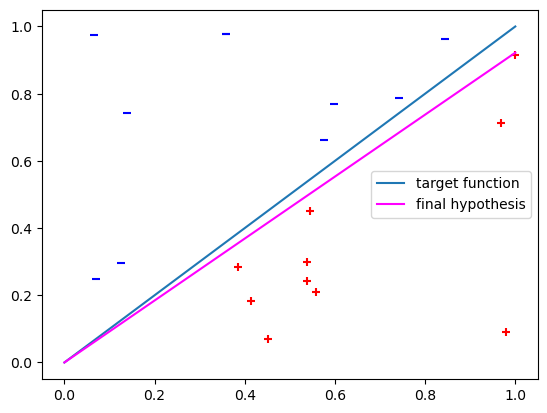

In [1]:
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt


# implements the perceptron
def h(x, w):
    return np.sign(np.dot(x, w))


# implements the PLA
def pla(data_x, data_y, w):
    for i in range(len(data_x)):
        x = np.array([1] + data_x[i])
        y = data_y[i]
        if (h(x, w) != y):
            return pla(data_x, data_y, w + y * x)
    return w


# visualizes classified points and final hypothesis
def plot(data, y, w, min_x, max_x):
    for i in range(len(y)):
        classification = h(np.array([1] + data[i]), w)
        marker = '+' if (classification == 1) else '_'
        color = 'red' if (y[i] == 1) else 'blue'
        plt.scatter(data[i][0], data[i][1], color=color, marker=marker)
    y1 = calcY(min_x, w)
    y2 = calcY(max_x, w)
    plt.plot([min_x, max_x], [y1, y2], color='magenta', label='final hypothesis')
    plt.legend(loc='best')
    plt.show()


def calcY(x, w):
    return -(w[0] + x * w[1]) / w[2]


def getDummyData(N):
    tf = lambda x: x  # target function
    X = np.random.rand(N, 2)  # data set
    labels = np.where(X[:, 0] < X[:, 1], -1, 1)
    return X, labels, tf


# for demonstration purposes only to get an idea of how to call the PLA function.
X, y, target_function = getDummyData(20)
w = pla(X.tolist(), y, np.zeros(len(X[0]) + 1))

# visualize results
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l), label='target function')
plot(X.tolist(), y, w, 0, 1)

In [2]:
def pla_pocket(x: np.ndarray, y: np.ndarray, iterations: int):
    x_stacked = np.hstack((np.ones(((x.shape[0], 1))), x))
    w_best = np.zeros(x_stacked.shape[1])
    w_curr = w_best.copy()
    bools_curr = h(x_stacked, w_best) != y
    err = np.sum(bools_curr) / bools_curr.shape[0]
    i = 0
    while i < iterations and err > 0:
        idx = bools_curr.argmax()
        x_k = x_stacked[idx]
        y_k = y[idx]
        w_curr = w_curr + y_k * x_k
        bools_curr = h(x_stacked, w_curr) != y
        err_temp = np.sum(bools_curr) / bools_curr.shape[0]
        if err_temp < err:
            w_best = w_curr.copy()
            err = err_temp
        i+=1
    return w_best

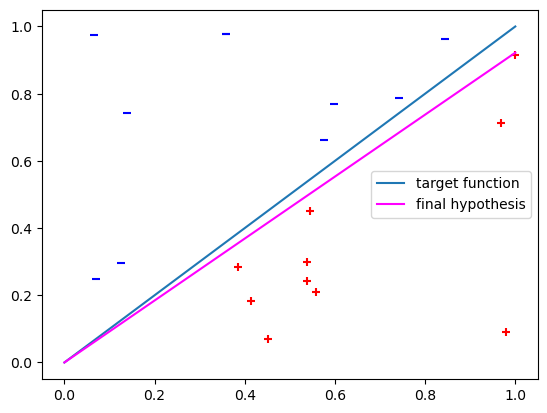

In [3]:
w = pla_pocket(X, y, 1000)

# visualize results
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l), label='target function')
plot(X.tolist(), y, w, 0, 1)

### 4.2 Testen des Pocket-Algorithmus auf synthetischen Daten
Wir werden den Pocket-Algorithmus auf synthetischen Daten testen, die **nicht** linear separierbar sind. Dazu möchte ich Sie bitten, einen synthetischen Datensatz zu erstellen und nachfolgend ein Experiment durchzuführen.

**Ihre Aufgaben**

(1) Unten finden Sie Code, der einen linear separierbaren Datensatz der Größe $N$ erstellt. Modifizieren Sie diesen Code, sodass er nicht mehr linear separierbare Datensätze erstellt. Gehen Sie wie folgt vor: Nach der Erzeugung eines linear separierbaren Datensatzes der Größe $N$ wählen Sie zufällig $\frac{N}{10}$ Datenpunkte aus und drehen die entsprechenden Labels (+1 bzw -1) um.

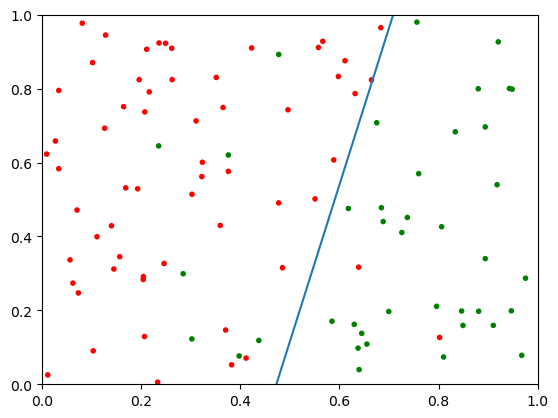

In [4]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def generate_points(N):
    return np.random.rand(N, 2)


def generate_decision_line():
    g = generate_points(2)
    m = (g[1, 1] - g[1, 0]) / (g[0, 1] - g[0, 0])
    b = g[1, 0] - m * g[0, 0]

    def getY(x):
        return m * x + b

    func = getY
    return func


def getClassedPoints(N):
    tf = generate_decision_line()  # target function
    X = generate_points(N)  # data set
    labels = np.array([1 if tf(X[i, 0]) > X[i, 1] else -1 for i in range(X.shape[0])])  # labels
    indices = np.random.choice(np.arange(labels.size), int(N/10))
    labels[indices] *= -1
    return X, labels, tf


# obtain points p, targets t, and decision line g
X, y, target_function = getClassedPoints(100)

# create color labels according to target values
lookup = np.array(["r", "g"])
c = lookup[(y + 1) // 2]

# plot points
plt.axis((0, 1, 0, 1))
plt.scatter(X[:, 0], X[:, 1], c=c, marker='.')

# plot decision line
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l))


(2) Erzeugen Sie einen solchen zufälligen Datensatz mit 200 Datenpunkten. Teilen Sie diesen erzeugten Datensatz in Trainingsset und Testset auf (je $N=100$ Datenpunkte). Wenden Sie den Pocket-Algorithmus für $T=1000$ Iterationen auf den Trainingsdatensatz an und speichern dabei $E_{in}(\mathbf{\hat{w}}^{(t)})$, $E_{in}(\mathbf{w}^{(t)})$, Gewichte $\mathbf{w}^{(t)}$ und $\mathbf{\hat{w}}^{(t)}$ für alle $t=1,\ldots,T-1$.

In [5]:
def pla_pocket_verbose(x: np.ndarray, y: np.ndarray, iterations: int) -> tuple[np.ndarray, list[float], np.ndarray, list[float]]:
    x_stacked = np.hstack((np.ones(((x.shape[0], 1))), x))
    w_bests = np.zeros((iterations + 1, x_stacked.shape[1]))
    w_currs = w_bests.copy()
    bools_curr = h(x_stacked, w_currs[0]) != y
    errs = [np.sum(bools_curr) / bools_curr.shape[0]]
    errs_curr = errs.copy()
    i = 0
    while i < iterations and errs[-1] > 0:
        w_best = w_bests[i]
        err = errs[-1]
        idx = bools_curr.argmax()
        x_k = x_stacked[idx]
        y_k = y[idx]
        w_curr = w_currs[i] + y_k * x_k
        bools_curr = h(x_stacked, w_curr) != y
        err_temp = np.sum(bools_curr) / bools_curr.shape[0]
        if err_temp < err:
            w_best = w_curr.copy()
            err = err_temp
        errs_curr.append(err_temp)
        errs.append(err)
        w_currs[i+1] = w_curr
        w_bests[i+1] = w_best
        i+=1
    return w_bests, errs, w_currs, errs_curr
(w_bests, ein_best, ws, eins) = pla_pocket_verbose(X, y, 1000)
print(len(ein_best))

1001


In [6]:

from sklearn.model_selection import train_test_split

def get_error_sequences(N: int):
    X, y, _ = getClassedPoints(N)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
    x_test_stacked = np.hstack((np.ones(((X_test.shape[0], 1))), X_test))

    (w_bests, ein_best, ws, eins) = pla_pocket_verbose(X_train, y_train, 1000)
    eout_best = []
    eouts = []
    for i in range(len(ein_best)):
        w_best = w_bests[i]
        w = ws[i]
        bools_best = h(x_test_stacked, w_best) != y_test
        eout_best.append(np.sum(bools_best) / bools_best.shape[0])
        bools = h(x_test_stacked, w) != y_test
        eouts.append(np.sum(bools) / bools.shape[0])
    return (ein_best, eins, eout_best, eouts)

get_error_sequences(100)

([np.float64(1.0),
  np.float64(0.56),
  np.float64(0.46),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.44),
  np.float64(0.36),
  np.float64(0.36),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.2),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),
  np.float64(0.16),


(3) Nutzen Sie die Labels für das Testset und die Gewichte $\mathbf{w}^{(t)}$ und $\mathbf{\hat{w}}^{(t)}$, um mithilfe des Perzeptrons die Out-of-Sample Fehler $E_{out}(\mathbf{\hat{w}}^{(t)})$ und $E_{out}(\mathbf{w}^{(t)})$ abzuschätzen, wobei $E_{out}$ als die Anzahl der Fehlklassifikationen im Testset dividiert durch die Testset-Größe definiert ist.

(4) Wiederholen Sie die Schritte 2 und 3 insgesamt 20 Mal, sodass Sie vier Matrizen mit je (1000x20) Einträgen für $E_{in}(\mathbf{w})$, $E_{in}(\mathbf{\hat{w}})$ und $E_{out}(\mathbf{w})$ sowie $E_{out}(\mathbf{\hat{w}})$ erhalten.

In [7]:
ein_best_matrix = []
ein_matrix = []
eout_best_matrix = []
eout_matrix = []

for i in range(20):
    (ein_best, eins, eout_best, eouts) = get_error_sequences(1000)
    ein_best_matrix.append(ein_best[1:])
    ein_matrix.append(eins[1:])
    eout_best_matrix.append(eout_best[1:])
    eout_matrix.append(eouts[1:])

ein_best_matrix = np.array(ein_best_matrix).T
ein_matrix = np.array(ein_matrix).T
eout_best_matrix = np.array(eout_best_matrix).T
eout_matrix = np.array(eout_matrix).T

(5) Berechnen Sie die Mittelwerte über die 20 Spalten für jede Matrix und erhalten Sie somit vier Vektoren, die die Mittelwerte der in Schritt 3 genannten Größen über die Zeit $t$ hinweg enthält. (Die Funktion [np.mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) kann hier für Sie hilfreich sein.)

In [8]:
ein_best_mean = ein_best_matrix.mean(1)
ein_mean = ein_matrix.mean(1)
eout_best_mean = eout_best_matrix.mean(1)
eout_mean = eout_matrix.mean(1)
print(ein_best_mean.shape)

(1000,)


(6) Plotten Sie in einer Abbildung die Mittelwerte von $E_{in}(\mathbf{w})$ und $E_{in}(\mathbf{\hat{w}})$ als Funktion des Iterationsschritts $t$. Welche Unterschiede fallen Ihnen auf? (1-2 Sätze)

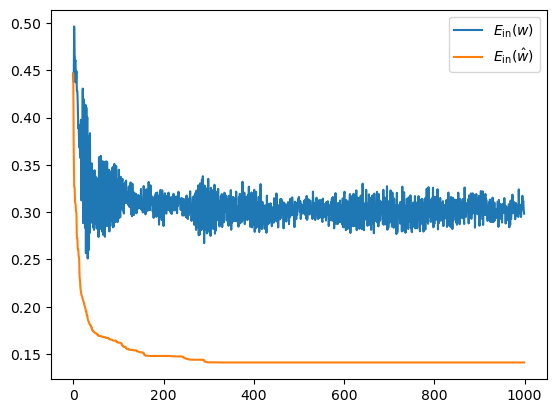

In [9]:
plt.plot(ein_mean, label="$E_\\text{in}(w)$")
plt.plot(ein_best_mean, label="$E_\\text{in}(\\hat{w})$")
plt.legend()
plt.show()

Es fällt auf, dass die Fehler von $\hat{w}$ monoton konvergent abfallen, während die Fehler von $w$ alternieren und in Durchschnitt höher sind.

(7) Plotten Sie in einer Abbildung die Mittelwerte von $E_{in}(\mathbf{\hat{w}})$ sowie $E_{out}(\mathbf{\hat{w}})$ als Funktion von $t$. Was fällt Ihnen auf? (1-2 Sätze)

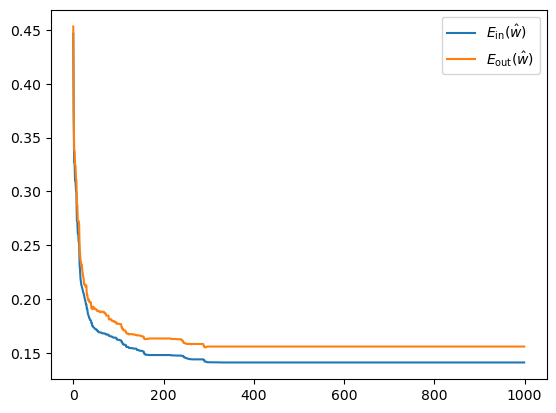

In [10]:
plt.plot(ein_best_mean, label="$E_\\text{in}(\\hat{w})$")
plt.plot(eout_best_mean, label="$E_\\text{out}(\\hat{w})$")
plt.legend()
plt.show()

Die Kurve von beiden ist sehr ähnlich, E_in ist dennoch immer etwas kleiner, als E_out

(8) Wiederholen Sie Schritt 7 für $E_{in}(\mathbf{w})$ sowie $E_{out}(\mathbf{w})$. Was fällt Ihnen auf? (1-2 Sätze)

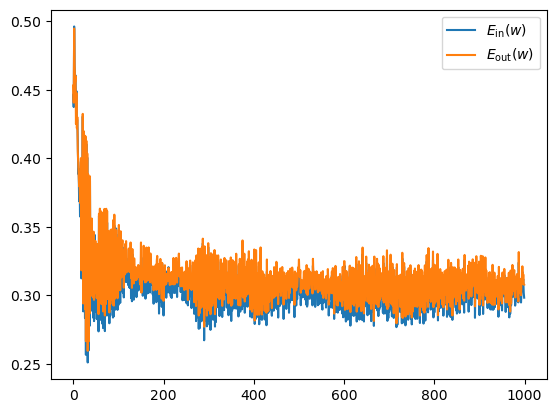

In [11]:
plt.plot(ein_mean, label="$E_\\text{in}(w)$")
plt.plot(eout_mean, label="$E_\\text{out}(w)$")
plt.legend()
plt.show()

Ebenso, wie $\hat{w}$, ist auch die Kurve von $w$ sehr ähnlich im E_in, wie im E_out, nur dass E_in ein bisschen kleiner ist.

### 4.3 Klassifikation handgeschriebener Ziffern
Die automatische Erkennung handgeschriebener Ziffern ist eine alt-bekannte Problemstellung im Machine Learning. Eine der frühesten Anwendungen findet sich im automatischen Erkennen von Postleitzahlen auf Briefumschlägen und beim Einlesen handgeschriebener Überweisungsträger.

Unser Ziel in dieser Übung ist es nicht, den perfekten Klassifikator zu bauen (denn dazu fehlen uns noch einige Kenntnisse). Stattdessen wollen wir mithilfe der unten vorgestellten Datensätze das Feature Engineering (deutsch: die Merkmalsgenerierung) üben, die Ihnen in angewandten Machine Learning Projekten immer wieder begegnen wird. Dann wollen wir mithilfe der Features eine der 10 Ziffern von den anderen 9 Ziffern mithilfe des Pocket-Algorithmus trennen.

Es gibt hier keine "richtige" oder "falsche" Lösung in diesem Übungsteil - Sie können sich entspannen. Es geht darum, neugierig und erfinderisch zu sein, um Features zu konstruieren, mit denen sich Ziffern voneinander unterscheiden lassen.

**Ihre Aufgaben**

(1) Machen Sie sich mit den unten aufgeführten Datensätzen vertraut. Entscheiden Sie sich dann für einen, mit dem Sie arbeiten wollen. Der erste Datensatz ist schnell zu berechnen (weil er sehr klein ist). Der zweite Datensatz liefert Ihnen eine bessere Auflösung, ist aber größer. Es gibt hier keine richtige oder falsche Entscheidung. Nutzen Sie einfach den Datensatz, der Ihnen vielversprechend erscheint (Sie können auch später noch den Datensatz wechseln, wenn Sie dies wünschen).
* Der "leichtgewichtige" Datensatz: Es handelt sich um handschriftliche Ziffern, die über ein Wacom-Tablet digitalisiert wurden. Jede Ziffer besteht aus einem kleinen Bild von 8x8 Graustufenwerten (also aus Matrizen der Größe 8x8). Wie viele handgeschriebenen Ziffern enthält der Datensatz? Wo befinden sich die Labels? Wo befinden sich die 8x8 Bilder?
* Der "klassische" Datensatz: Diesen gibt es in vielen Varianten, und wir nutzen hier eine davon. Er enthält Graustufenbilder von Ziffern der Größe 16x16 (als Vektoren der Größe 256). Wie viele handgeschriebenen Ziffern enthält der Datensatz? Wo befinden sich die Labels?

Keys:  dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


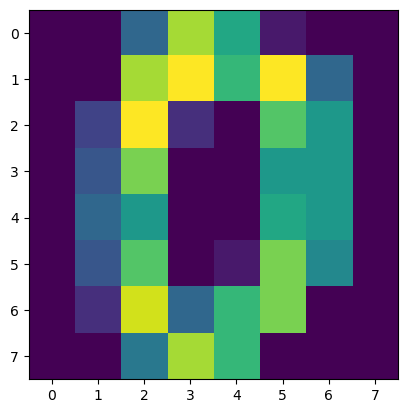

In [12]:
# Den "leichtgewichtige" Datensatz finden Sie hier.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
print('Keys: ', digits.keys())

plt.imshow(digits.images[0])

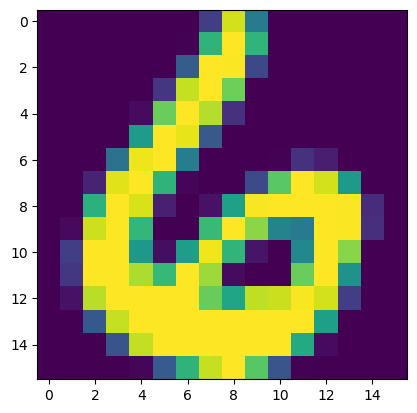

In [13]:
import requests
# Den "klassische" Datensatz finden Sie hier.
from scipy.io import savemat, loadmat
import numpy as np
from matplotlib import pyplot as plt

# Wenn Sie offline arbeiten wollen, finden Sie die Datei
# zum Download hier: https://data.bialonski.de/ml/digits_dataset.mat
file = requests.get('https://data.bialonski.de/ml/digits_dataset.mat')
data = loadmat(BytesIO(file.content))

plt.imshow(np.reshape(data['train_data'][0],(16,16)))

In [14]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'train_data', 'train_targets', 'test_data', 'test_targets'])


In [15]:
print(data["train_data"].shape)

(7291, 256)


In [16]:
print(data["test_data"].shape)

(2007, 256)


Der größere Datensatz enthält 9298 Zahlen. Die Features befinden sich in train_targets und test_targets

(2) Visualisieren Sie Beispiele für jede der Ziffern 0 bis 9. Sie können dazu die matplotlib-Funktion `imshow` verwenden sowie mithilfe des Vektors, der die Labels enthält, nach Beispielen suchen.

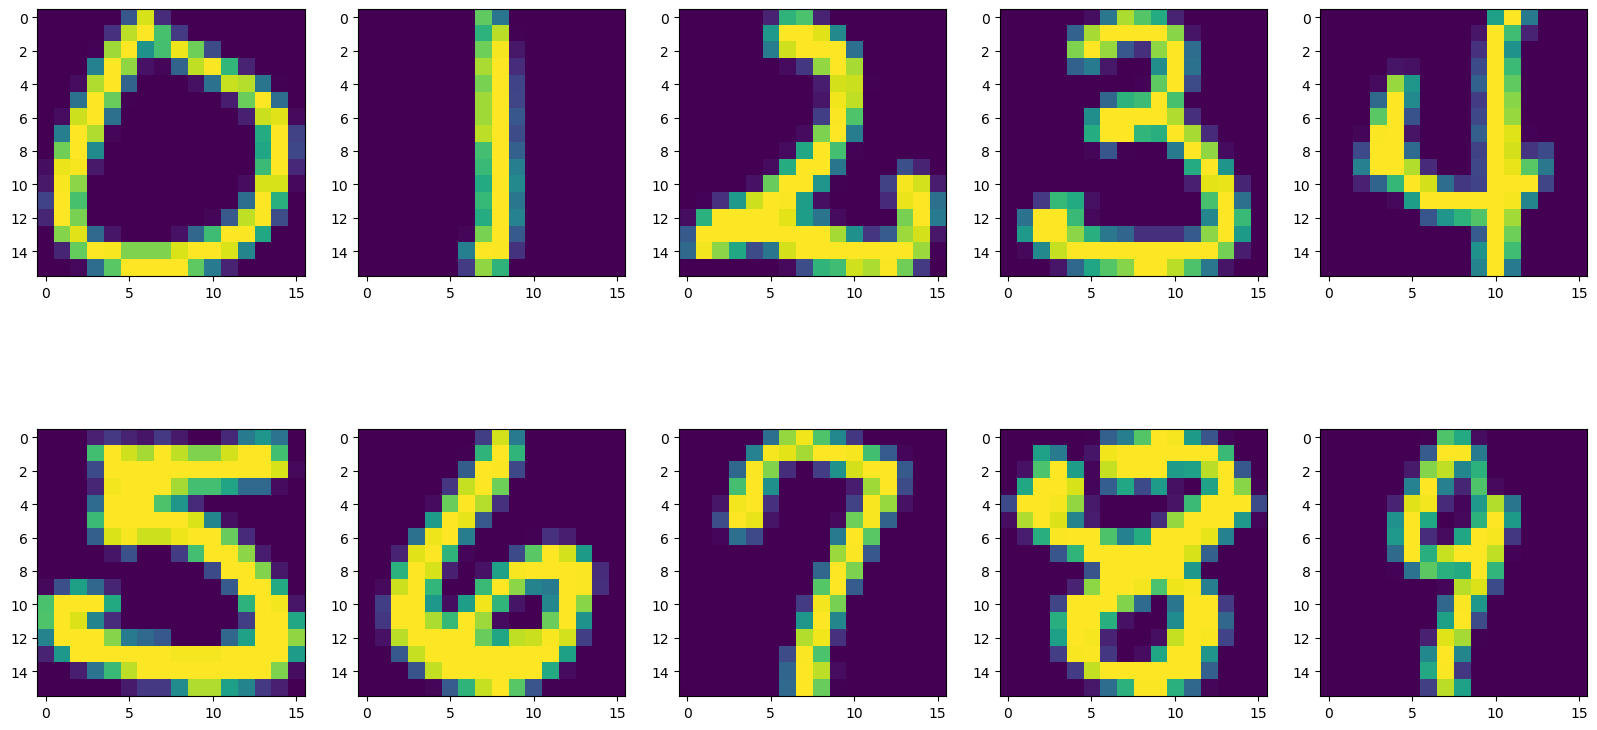

In [17]:
_, ax = plt.subplots(2, 5, figsize=(20, 10))
ax = ax.flatten()
_, indexes = np.unique(data["train_targets"], return_index=True)

for i, k in enumerate(indexes):
    ax[i].imshow(np.reshape(data['train_data'][k],(16,16)))
plt.show()

(3) Betrachten Sie die Beispiele aus dem Schritt (2) und nehmen Sie sich Zeit:
* Worin könnten sich die Ziffern unterscheiden?
* Gibt es vielleicht eine Ziffer, die sich leichter von allen anderen Ziffern unterscheiden lässt?
* Wie könnten Sie diese Unterschiede durch einfache Operationen (z.B. Gesamtgröße aller Graustufenwerte, Graustufenmittelwerte /-standardabweichungen, Symmetrien, etc) charakterisieren? Was für Features könnten Sie definieren? Schreiben Sie Ihre Ideen gerne kurz für Sie selbst auf.

Es kann der Prozentanteil der Schwarzen Pixel als Unterscheidung genommen werden. Es kann aber auch die Horizontale und Vertikale Symetrie, sowie eine Diagonale Symmetrie verwendet werden.

Ich denke, dass man die 1 sehr gut, durch die Menge der Schwarzen Pixel trennen kann. Andere Faktoren, um die 1 zu finden, wäre auch die Symmetrie.

(4) Entscheiden Sie sich für eine Ziffer, die sie von den anderen Ziffern trennen wollen.

0

(5) Entscheiden Sie sich für zwei Features aus Schritt (3), implementieren Sie sie und berechnen Sie Ihre Features für jede Ziffer des Datensatzes.

* Es ist gute Praxis, Ihre Features zu normieren, sodass Sie (beispielsweise) alle im Interval \[0, 1\] liegen. Da viele Lernalgorithmen empfindlich auf unskalierte Features reagieren, skalieren Sie nun schon hier Ihre Features entsprechend.
* Erzeugen Sie einen Scatterplot, der die Datenpunkte in Ihrer Feature-Ebene zeigt (also Feature 1 versus Feature 2 für jede Ziffer), wobei Sie Ihre ausgewählte Ziffer aus Schritt (4) mit einem anderen Symbol markieren als alle anderen.

In [82]:
X: np.ndarray = data['train_data']
# Summe der Pixel
sum_of_values = X.sum(axis=1) 
# Z-Scoring, um keine Ungleichkeit in die Features zu bringen
sum_of_values = (sum_of_values - np.average(sum_of_values)) / np.std(sum_of_values) 

# Anz der gleichen Pixel, wenn das Bild in dev Diagonalen gespiegelt wird
diagonal_symmetricity = (X.reshape((X.shape[0], 16, 16)) == X.reshape((X.shape[0], 16, 16)).transpose((0, 2, 1)).copy()).reshape(X.shape[0], X.shape[1]).sum(axis=1) 
# Z-Scoring
diagonal_symmetricity = (diagonal_symmetricity - np.average(diagonal_symmetricity)) / np.std(diagonal_symmetricity) 
for number in np.unique(data["train_targets"]):
    print(f"{number=}")
    print("Label 1: ", np.average(sum_of_values[data["train_targets"][0] == number]))
    print("Label 2: ", np.average(diagonal_symmetricity[data["train_targets"][0] == number]))


x_train = np.c_[sum_of_values, diagonal_symmetricity]
print(x_train.shape)

number=np.float64(0.0)
Label 1:  1.0331280167814072
Label 2:  -0.2100755948470996
number=np.float64(1.0)
Label 1:  -1.1429999504421575
Label 2:  1.5694147966534013
number=np.float64(2.0)
Label 1:  0.25999459767125876
Label 2:  -0.5391232419020384
number=np.float64(3.0)
Label 1:  0.31205793100188645
Label 2:  -0.9835864380442284
number=np.float64(4.0)
Label 1:  -0.42416641608601624
Label 2:  0.5252443942003115
number=np.float64(5.0)
Label 1:  0.36207288488776757
Label 2:  -0.7010762334870466
number=np.float64(6.0)
Label 1:  -0.019274109060784323
Label 2:  -0.1628651828894485
number=np.float64(7.0)
Label 1:  -0.498758979302146
Label 2:  0.25982419741343754
number=np.float64(8.0)
Label 1:  0.25153706196988573
Label 2:  -0.6163720134609685
number=np.float64(9.0)
Label 1:  -0.32115159871197696
Label 2:  0.05719860539941953
(7291, 2)


In [ ]:
X_test: np.ndarray = data['test_data']
# Anz der Schwarzen Pixel
summ_of_pixels_test = X_test.sum(axis=1) 
# Z-Scoring
summ_of_pixels_test = (summ_of_pixels_test - np.average(summ_of_pixels_test)) / np.std(summ_of_pixels_test) 

# Anz der gleichen Pixel, wenn das Bild in dev Diagonalen gespiegelt wird
vertical_symmetricity_test = (X_test.reshape((X_test.shape[0], 16, 16)) == X_test.reshape((X_test.shape[0], 16, 16)).transpose((0, 2, 1)).copy()).reshape(X_test.shape[0], X_test.shape[1]).sum(axis=1) 
vertical_symmetricity_test = (vertical_symmetricity_test - np.average(vertical_symmetricity_test)) / np.std(vertical_symmetricity_test) 

x_test = np.c_[summ_of_pixels_test, vertical_symmetricity_test]
print(x_test.shape)

(2007, 2)


(6) Sind Sie zufrieden mit Ihren Features? Falls nein, können Sie unten einen Hinweis lesen. Falls Sie zufrieden sind, erzeugen Sie einen neuen Label-Vektor, sodass ein Label (z.B. +1) für Ihre aus Schritt (4) zugewiesene Ziffer vergeben wird, während alle anderen Ziffern ein anderes Label (z.B. -1) erhalten. Teilen Sie nun den Datensatz in ein Trainings- (etwa 75% des gesamten Datensatzes) und Testset (etwa 25%) auf. (Wenn Sie den klassischen Datensatz verwenden, sind die Daten für Sie schon in den entsprechenden Variablen aufgeteilt worden.)

In [55]:
y = np.where(data["train_targets"] == 1, 1, -1)[0]
y_test = np.where(data["test_targets"] == 1, 1, -1)[0]
print(y.shape, y_test.shape)

(7291,) (2007,)


(7) Wenden Sie den Pocket-Algorithmus auf Ihr Trainingsset an (wählen Sie beispielsweise $T=1000$) und berechnen den finalen In-Sample-Fehler. Nutzen Sie die finale Hypothese (also das finale Gewicht des Pocket-Algorithmus), um den Out-of-Sample Fehler auf dem Testset zu bestimmen. Geben Sie Ihren erreichen In- und Out-of-Sample Fehler für Ihre gewählte Ziffer an. Hinweis: Nutzen Sie dieselben Definitionen des In- und Out-of-Sample Fehlers wie in Übung 4.2.

In [56]:
w = pla_pocket(x_train, y, 1000)
x_stacked = np.hstack((np.ones(((x_train.shape[0], 1))), x_train))
y_pred = h(x_stacked, w)
print(f"E_in = {(y != y_pred).sum() / y.shape[0]}")

E_in = 0.06432588122342614


910


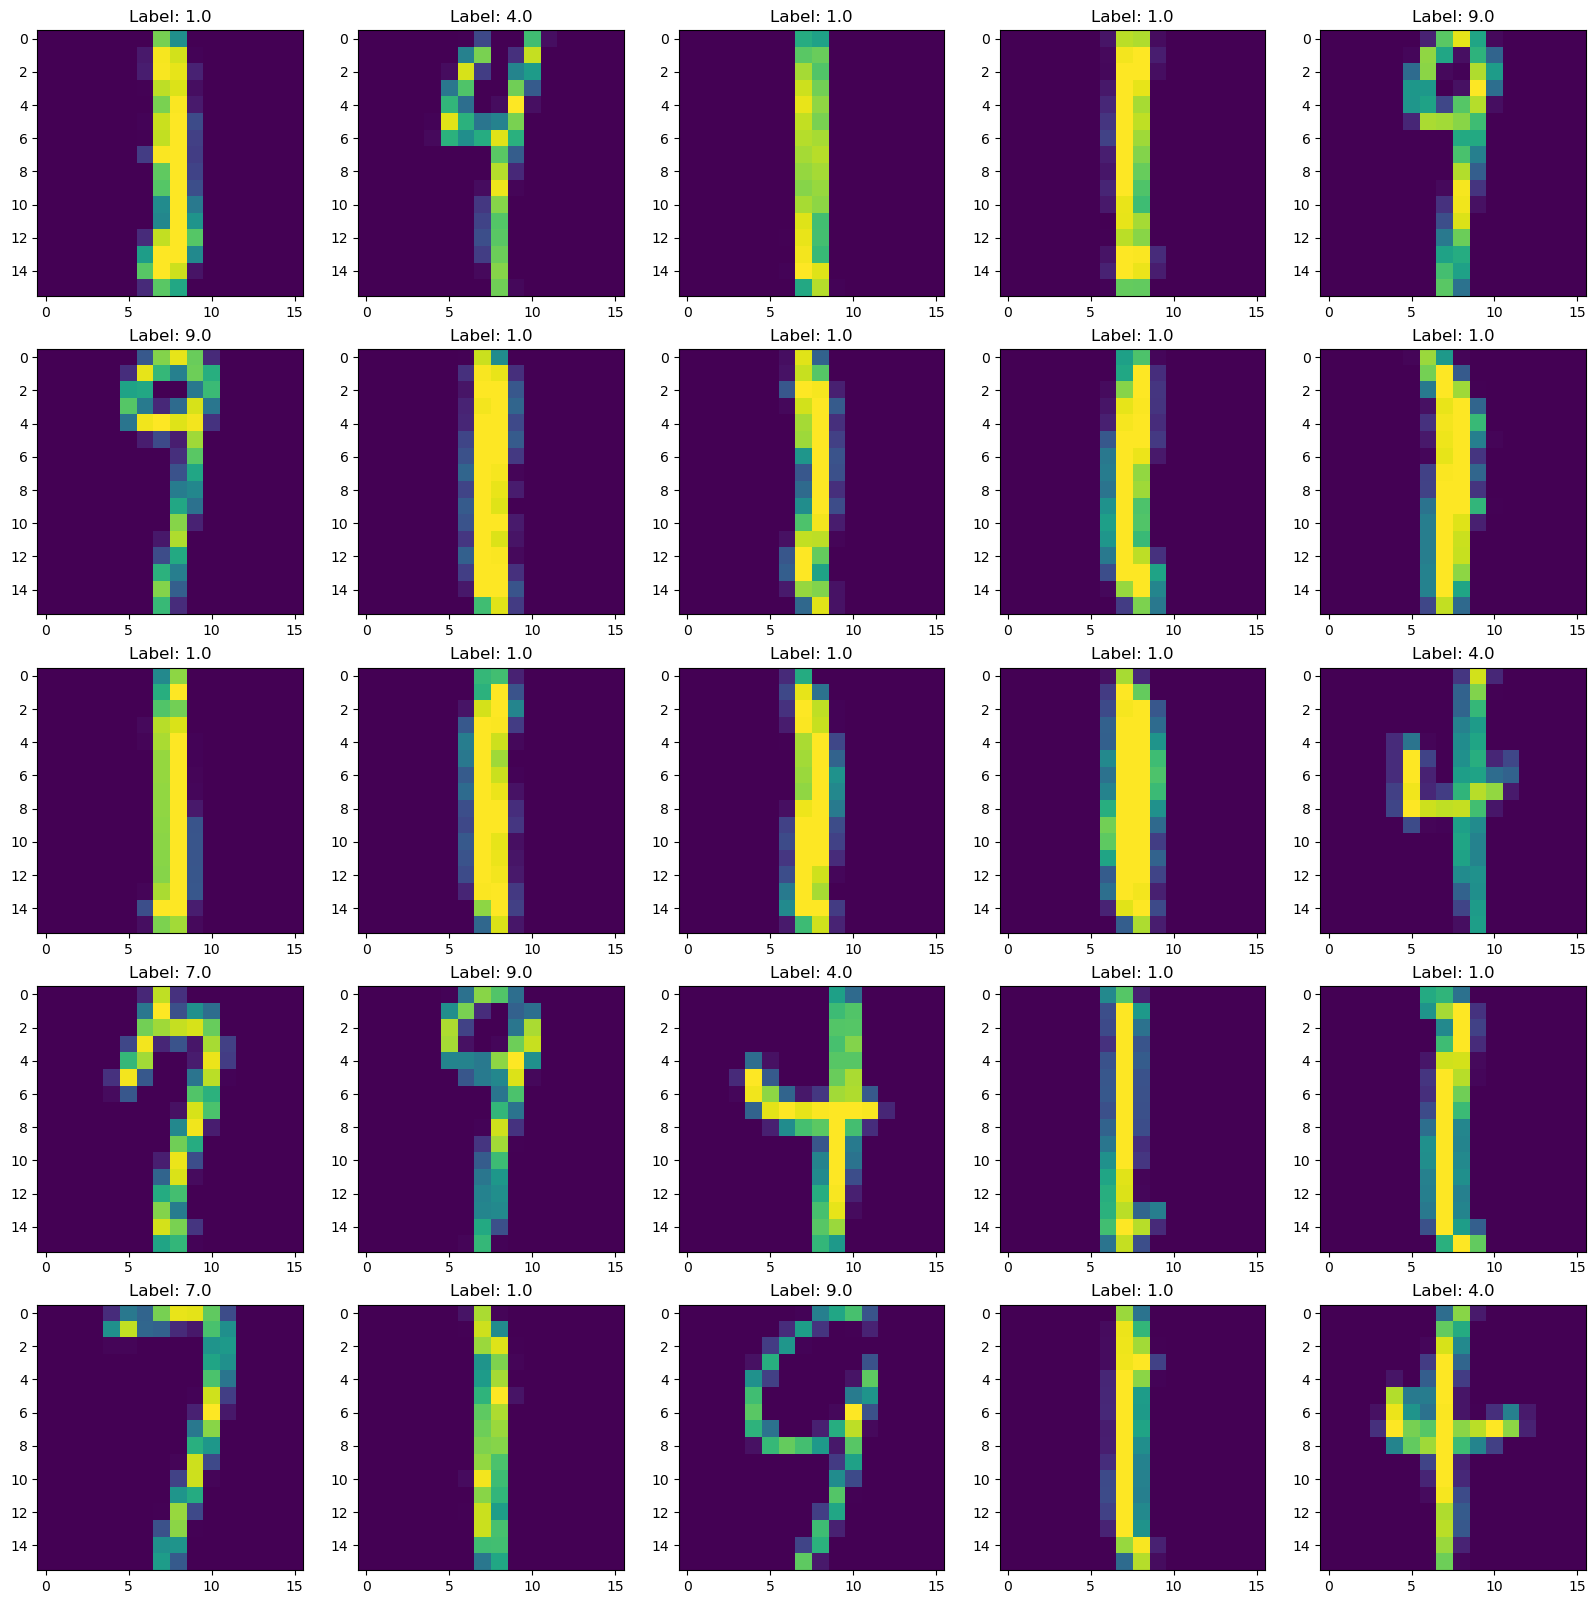

In [65]:
predicted_zeros = X[y_pred == 1]
predicted_zeros_actual = data["train_targets"][0][y_pred == 1]

print(predicted_zeros.shape[0])
idx = np.random.choice(np.arange(predicted_zeros.shape[0]), 25)
predicted_zeros_nine = predicted_zeros[idx]
predicted_zeros_nine_actual = predicted_zeros_actual[idx]

_, ax = plt.subplots(5, 5, figsize=(20, 20))
ax = ax.flatten()

for i, x in enumerate(predicted_zeros_nine):
    ax[i].imshow(np.reshape(x,(16,16)))
    ax[i].set_title(f"Label: {predicted_zeros_nine_actual[i]}")

plt.show()

In [58]:
x_test_stacked = np.hstack((np.ones(((x_test.shape[0], 1))), x_test))
y_pred_test = h(x_test_stacked, w)
print(f"E_out = {(y_test != y_pred_test).sum() / y_test.shape[0]}")

E_out = 0.06626806178375685


243


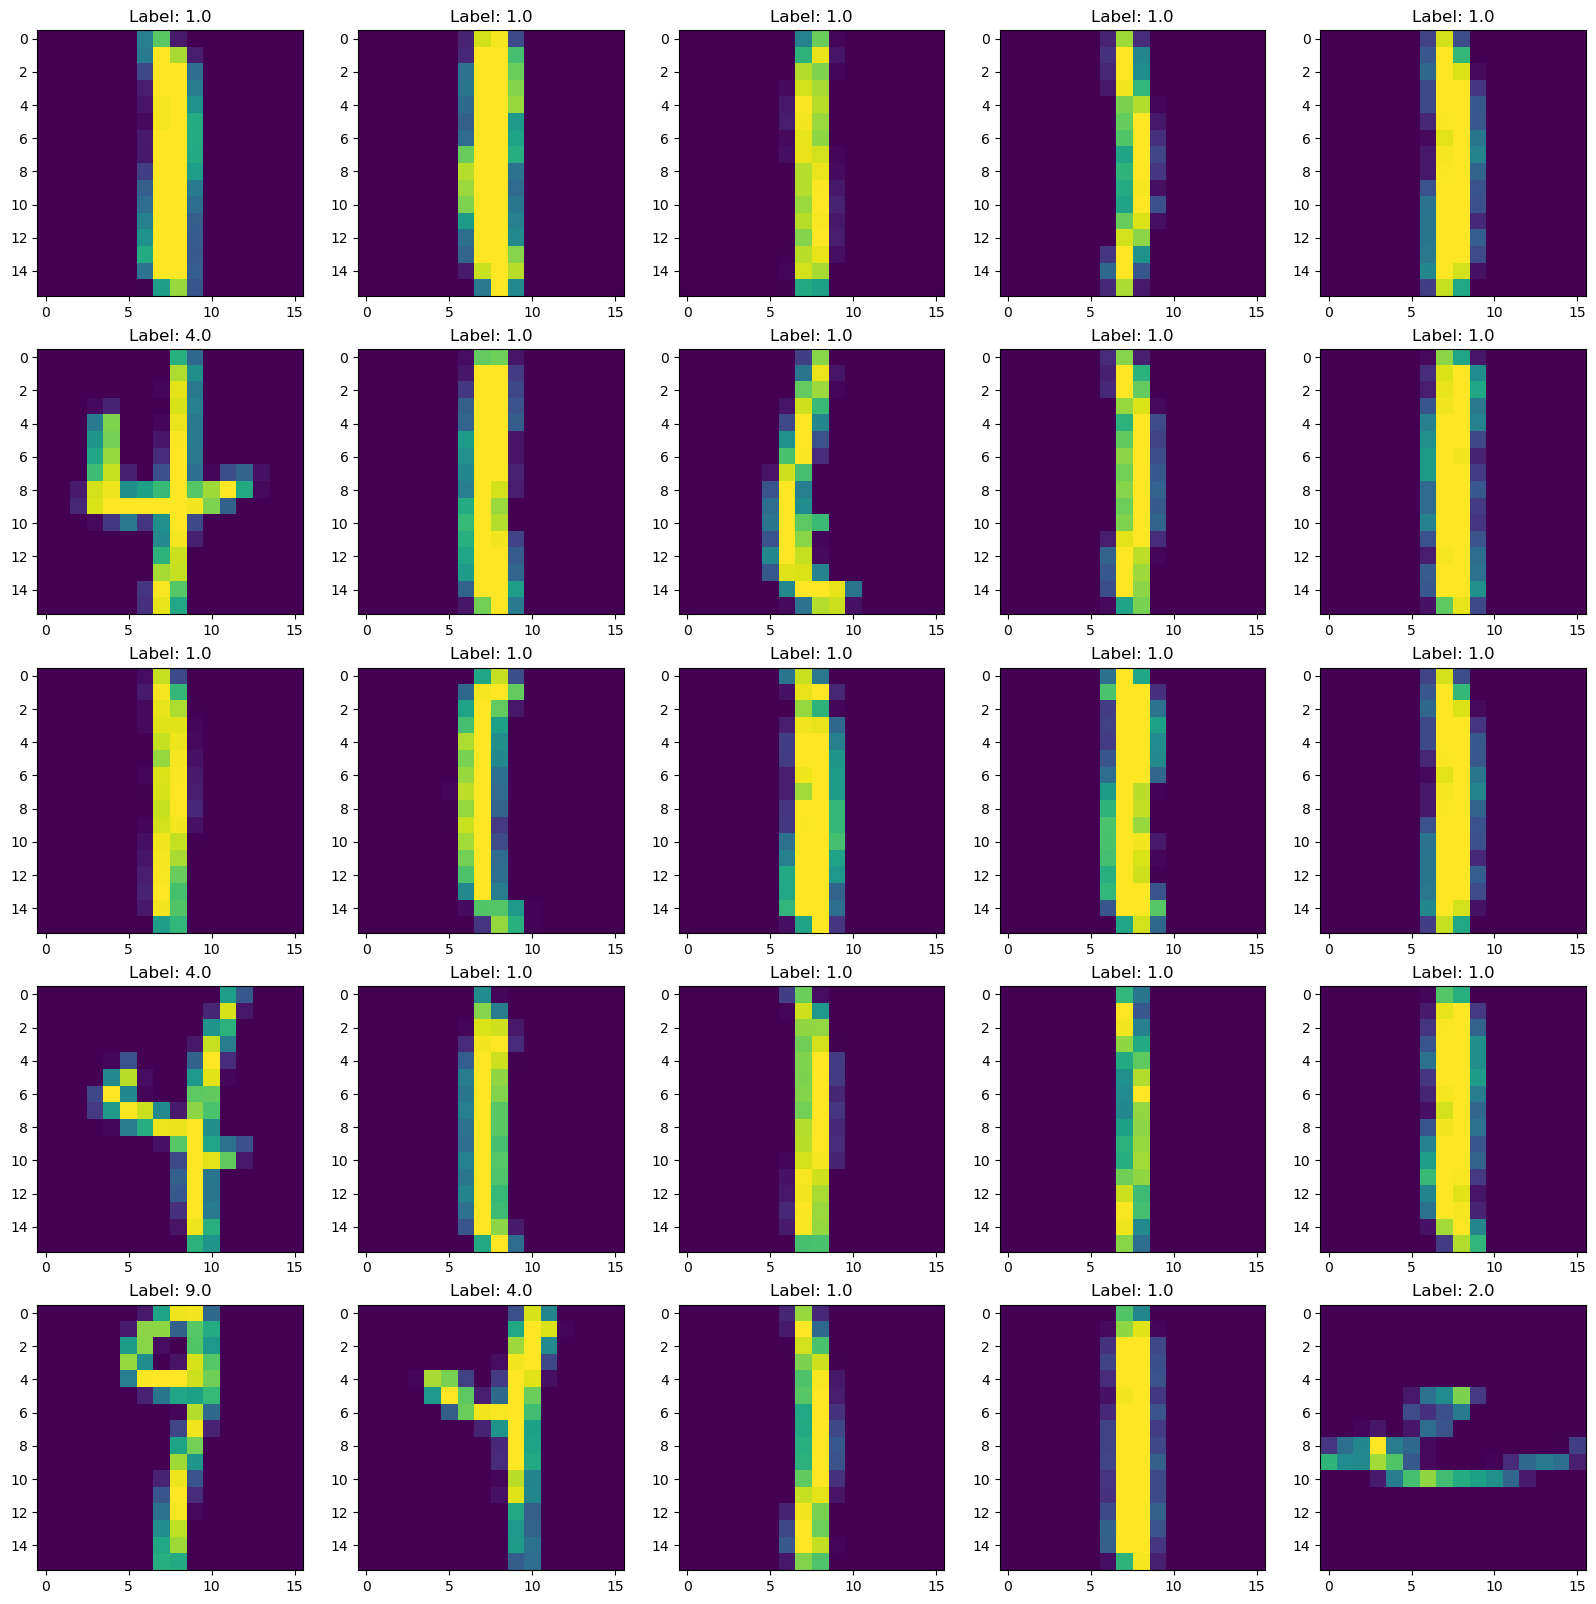

In [68]:
predicted_zeros_test = X_test[y_pred_test == 1]
predicted_zeros_actual_test = data["test_targets"][0][y_pred_test == 1]

print(predicted_zeros_test.shape[0])
idx = np.random.choice(np.arange(predicted_zeros_test.shape[0]), 25)
predicted_zeros_nine = predicted_zeros_test[idx]
predicted_zeros_nine_actual_test = predicted_zeros_actual_test[idx]

_, ax = plt.subplots(5, 5, figsize=(20, 20))
ax = ax.flatten()

for i, x in enumerate(predicted_zeros_nine):
    ax[i].imshow(np.reshape(x,(16,16)))
    ax[i].set_title(f"Label: {predicted_zeros_nine_actual_test[i]}")

plt.show()

**Hinweis:** Vermutlich waren Sie mit Ihren Features aus Schritt (6) unzufrieden und lesen nun daher diesen Hinweis. Lassen Sie sich nicht entmutigen. *Feature Engineering* ist ein nicht-trivialer Arbeitsschritt. Ich habe Ihnen eine Idee hier aufgeschrieben. Damit Sie sie nur dann lesen, wenn Sie wirklich keine Ideen haben, habe ich den Tipp mit ROT13 verschlüsselt. Kopieren Sie einfach den verschlüsselten Text und lassen Sie ihn [hier](https://rot13.de/) entschlüsseln.

Qvrfre Gvcc tvog Vuara xrvar Tnenagvr süe rvara Resbyt, fbaqrea jveq Fvr (ubssragyvpu) vafcvevrera: Süe qra xynffvfpura Qngrafngm xöaara Fvr mhz Orvfcvry irefhpura, qvr Mvssre "Rvaf" iba nyyra naqrera mh geraara. Qvr "Rvaf" oryrtg jravtr Cvkry (Srngher 1) haq vfg glcvfpurejrvfr flzzrgevfpu hz qvr ubevmbagnyr Npufr nyf nhpu hz qvr iregvxnyr Npufr (Srngher 2). Zrva Gvcc jäer nyfb, nyf refgrf Srngher qvr Fhzzr nyyre Tenhfghsrajregr ceb 16k16 Ovyq mh aruzra (qvr "Rvaf" jveq uvre irezhgyvpu xyrvarer Fhzzra retrora nyf naqrer Mvssrea). Nyf mjrvgrf Srngher xöaara Fvr qvr Nflzzrgevr va qra 16k16 Cvkryovyqrea punenxgrevfvrera: Fhogenuvrera Fvr rvasnpu iba wrqrz Ovyq qnf hz qvr iregvxnyr Npufr trfcvrtrygr Ovyq cvkryjrvfr haq fhzzvrera qvr Nofbyhgorgeätr qre cvkryjrvfra Qvssreramra nhs. Jvrqreubyra Fvr qnf Tyrvpur süe rvar Fcvrtryhat hz qvr ubevmbagnyr Npufr. Ovyqra Fvr nz Raqr qra Zvggryjreg qvrfre orvqra Fhzzra. Qnf xöaagr vue mjrvgrf Srngher jreqra.
Süe qra yrvpugtrjvpugvtra Qngrafngm jveq qvrfrf Ibetrura avpug frue thg shaxgvbavrera. Vpu rezhgvtr Fvr, rvtrar Srngherf mh svaqra, qvr qvr Mvssrea thg ibarvanaqre geraara. Va qre Iretnatraurvg unora fvpu mhz Orvfcvry sbytraqr Vqrra nyf uvyservpu rejvrfra: Qvr Namnuy na "Üoretäatra" mjvfpura uryyra haq qhaxyra Cvkrya va qra Fcnygra rvarf Ovyqf (trzrffra üore qvr Qvssreramra iregvxny oranpuonegre Cvkry), qvr Fhzzr qre Cvkryjregr trjvpugrg zvg qre Ragsreahat qre Cvkry mhe iregvxnyra Zvggryyvavr.

Versuch der horizontalen Symmetrie:

In [75]:
X: np.ndarray = data['train_data']
# Anz der Schwarzen Pixel
sum_of_values = X.sum(axis=1) 
# Z-Scoring
sum_of_values = (sum_of_values - np.average(sum_of_values)) / np.std(sum_of_values) 

# Anz der gleichen Pixel, wenn das Bild in dev Diagonalen gespiegelt wird
vertical_symetricity = (X.reshape((X.shape[0], 16, 16)) == np.flip(X.reshape((X.shape[0], 16, 16)).copy(), 1)).reshape(X.shape[0], X.shape[1]).sum(axis=1) 
vertical_symetricity = (vertical_symetricity - np.average(vertical_symetricity)) / np.std(vertical_symetricity) 
for number in np.unique(data["train_targets"]):
    print(f"{number=}")
    print("Label 1: ", np.average(sum_of_values[data["train_targets"][0] == number]))
    print("Label 2: ", np.average(vertical_symetricity[data["train_targets"][0] == number]))


x_train = np.c_[sum_of_values, vertical_symetricity]
print(x_train.shape)

number=np.float64(0.0)
Label 1:  1.0331280167814072
Label 2:  -0.3021350548159816
number=np.float64(1.0)
Label 1:  -1.1429999504421575
Label 2:  1.9393294686627123
number=np.float64(2.0)
Label 1:  0.25999459767125876
Label 2:  -0.5495324906427325
number=np.float64(3.0)
Label 1:  0.31205793100188645
Label 2:  -0.3383614077837448
number=np.float64(4.0)
Label 1:  -0.42416641608601624
Label 2:  -0.0591766201525582
number=np.float64(5.0)
Label 1:  0.36207288488776757
Label 2:  -0.7565066216912043
number=np.float64(6.0)
Label 1:  -0.019274109060784323
Label 2:  -0.4989229704108774
number=np.float64(7.0)
Label 1:  -0.498758979302146
Label 2:  -0.034138061599946014
number=np.float64(8.0)
Label 1:  0.25153706196988573
Label 2:  -0.14056588399712763
number=np.float64(9.0)
Label 1:  -0.32115159871197696
Label 2:  -0.1168250844148977
(7291, 2)


In [77]:
X_test: np.ndarray = data['test_data']
# Anz der Schwarzen Pixel
summ_of_pixels_test = X_test.sum(axis=1) 
# Z-Scoring
summ_of_pixels_test = (summ_of_pixels_test - np.average(summ_of_pixels_test)) / np.std(summ_of_pixels_test) 

# Anz der gleichen Pixel, wenn das Bild in dev Diagonalen gespiegelt wird
vertical_symmetricity_test = (X_test.reshape((X_test.shape[0], 16, 16)) == np.flip(X_test.reshape((X_test.shape[0], 16, 16)).copy(), 1)).reshape(X_test.shape[0], X_test.shape[1]).sum(axis=1) 
vertical_symmetricity_test = (vertical_symmetricity_test - np.average(vertical_symmetricity_test)) / np.std(vertical_symmetricity_test) 

x_test = np.c_[summ_of_pixels_test, vertical_symmetricity_test]

In [78]:
w = pla_pocket(x_train, y, 1000)
x_stacked = np.hstack((np.ones(((x_train.shape[0], 1))), x_train))
y_pred = h(x_stacked, w)
print(f"E_in = {(y != y_pred).sum() / y.shape[0]}")

E_in = 0.0046632835002057334


243


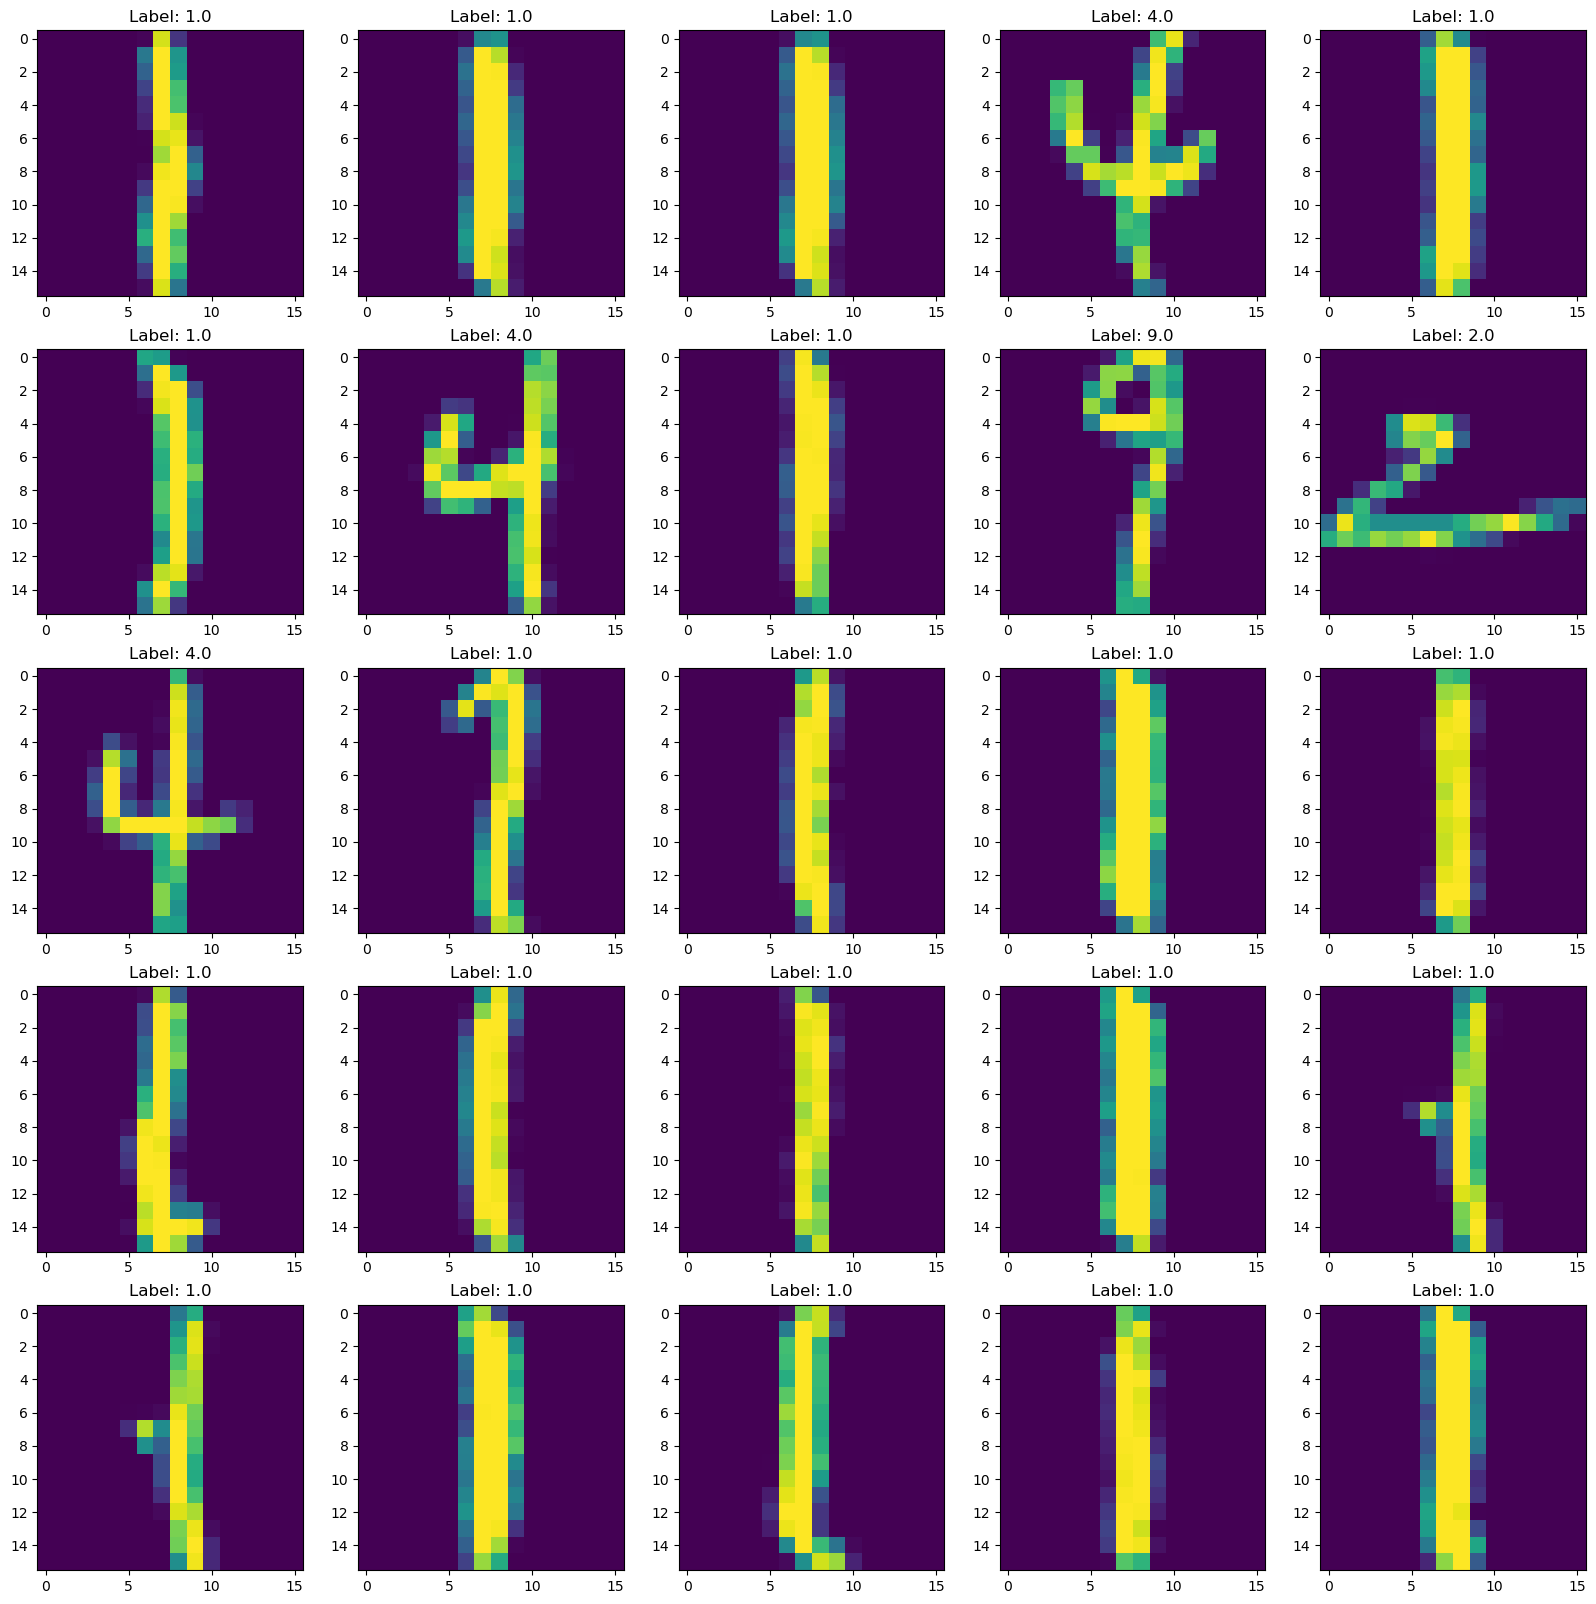

In [79]:
predicted_zeros_test = X_test[y_pred_test == 1]
predicted_zeros_actual_test = data["test_targets"][0][y_pred_test == 1]

print(predicted_zeros_test.shape[0])
idx = np.random.choice(np.arange(predicted_zeros_test.shape[0]), 25)
predicted_zeros_nine = predicted_zeros_test[idx]
predicted_zeros_nine_actual_test = predicted_zeros_actual_test[idx]

_, ax = plt.subplots(5, 5, figsize=(20, 20))
ax = ax.flatten()

for i, x in enumerate(predicted_zeros_nine):
    ax[i].imshow(np.reshape(x,(16,16)))
    ax[i].set_title(f"Label: {predicted_zeros_nine_actual_test[i]}")

plt.show()

In [80]:
x_test_stacked = np.hstack((np.ones(((x_test.shape[0], 1))), x_test))
y_pred_test = h(x_test_stacked, w)
print(f"E_out = {(y_test != y_pred_test).sum() / y_test.shape[0]}")

E_out = 0.014449427005480818


257


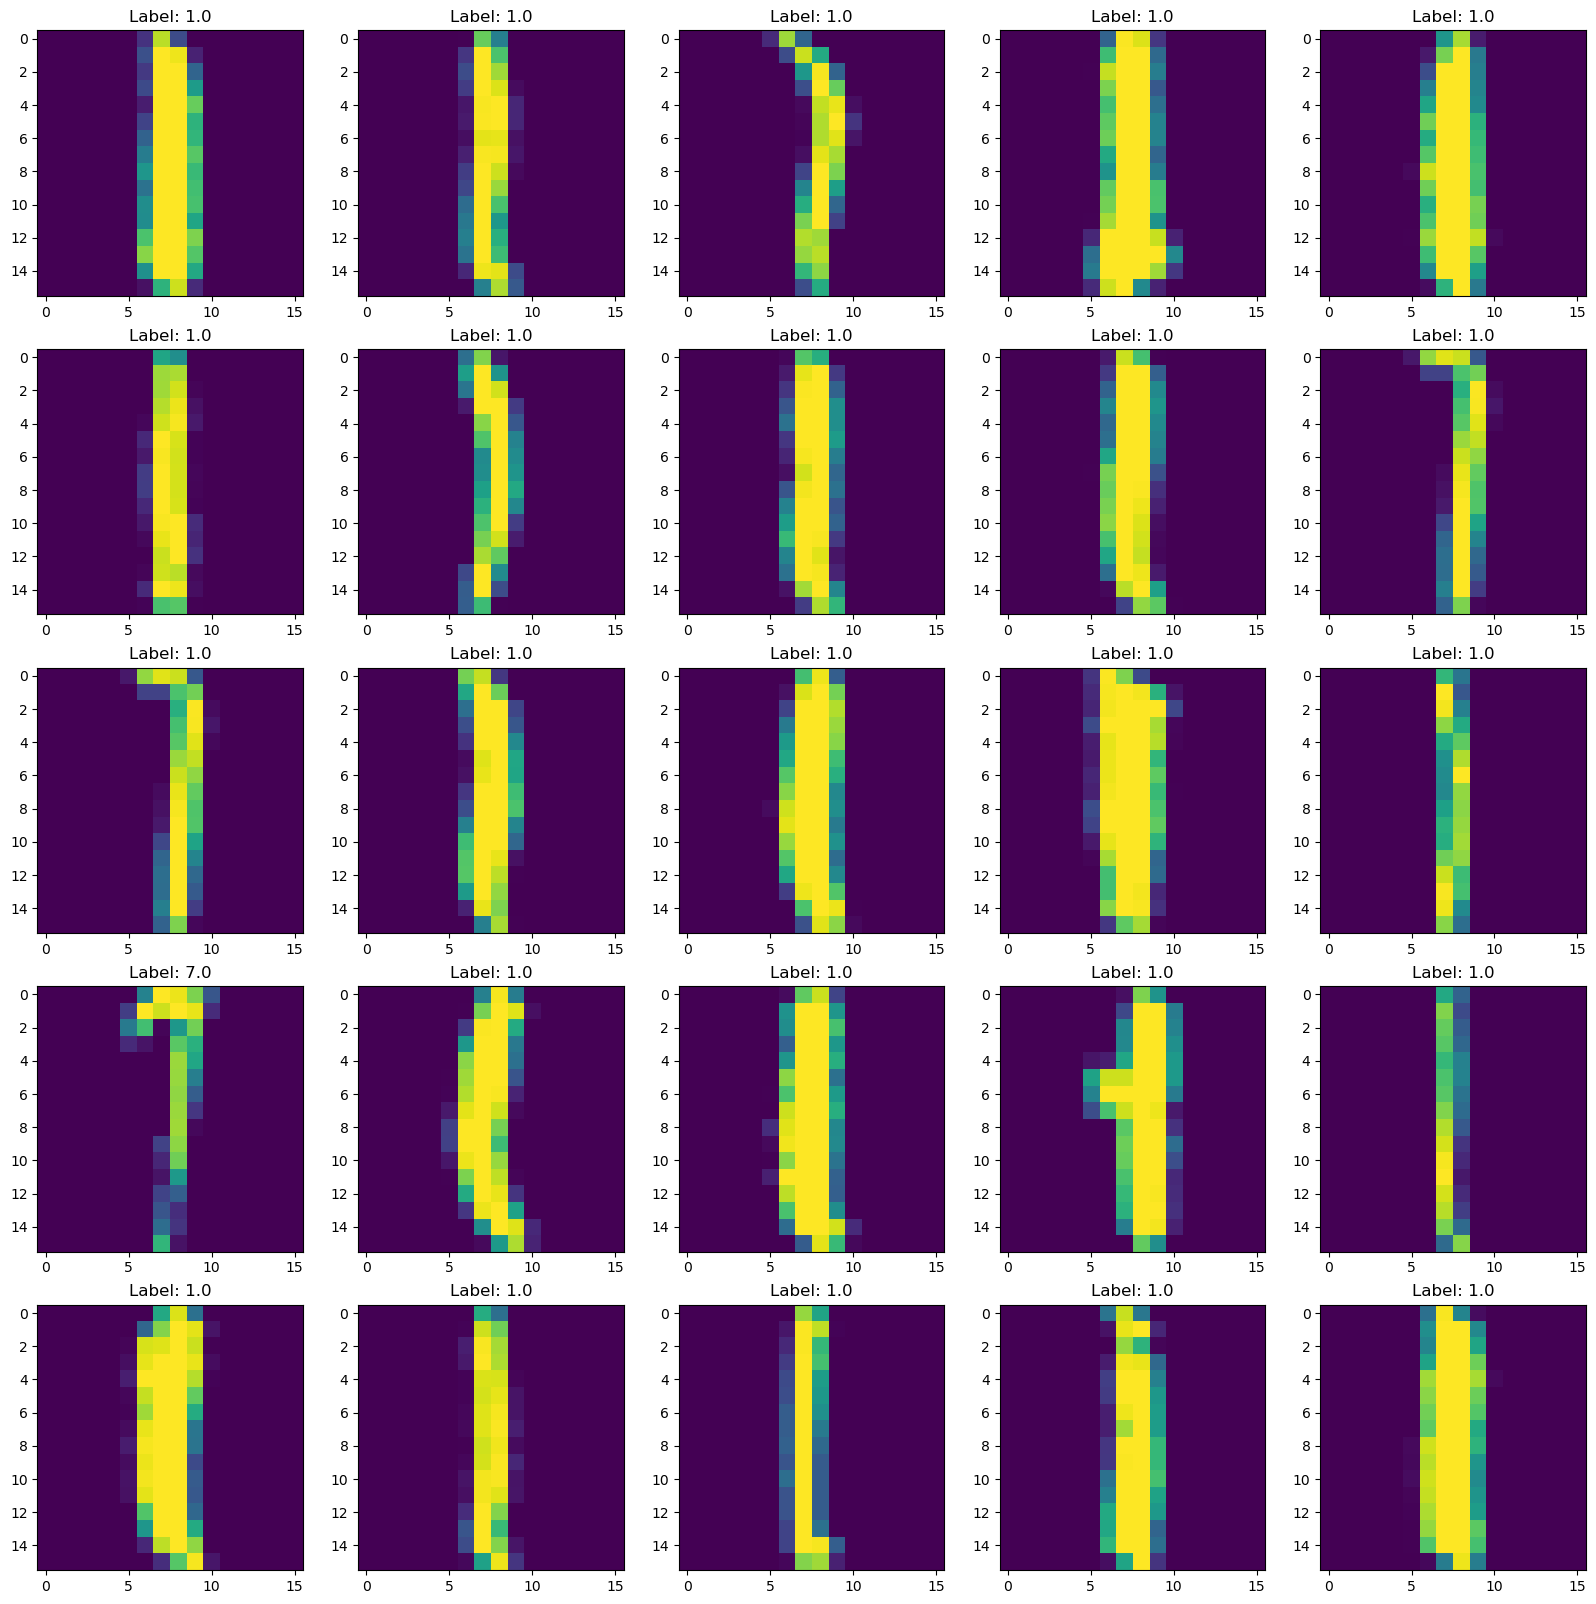

In [81]:
predicted_zeros_test = X_test[y_pred_test == 1]
predicted_zeros_actual_test = data["test_targets"][0][y_pred_test == 1]

print(predicted_zeros_test.shape[0])
idx = np.random.choice(np.arange(predicted_zeros_test.shape[0]), 25)
predicted_zeros_nine = predicted_zeros_test[idx]
predicted_zeros_nine_actual_test = predicted_zeros_actual_test[idx]

_, ax = plt.subplots(5, 5, figsize=(20, 20))
ax = ax.flatten()

for i, x in enumerate(predicted_zeros_nine):
    ax[i].imshow(np.reshape(x,(16,16)))
    ax[i].set_title(f"Label: {predicted_zeros_nine_actual_test[i]}")

plt.show()

Ergebnis: Sowohl der In-Sample-Fehler, als auch der Out-Of-Sample Fehler werden durch die vertikale, als die Diagonale Symmetrie als Feature 2 besser beschrieben.